---
title: "Logistic Regression"
format: 
    html: 
        toc: true
execute: 
  enabled: true
bibliography: "../../references.bib"
jupyter: python3
---

In this example, we construct a DIRT approximation to the posterior arising from applying (Bayesian) logistic regression to the well-known German credit dataset [@Hofmann1994]. To construct the DIRT approximation efficiently, we compute a Laplace approximation to the posterior and use this as a starting point to form the DIRT.

# Problem Setup

The German credit dataset contains a binary response variable, $\boldsymbol{y} \in \mathbb{R}^{m}$, where $m = 1000$. Each value $y_{i}$ corresponds to a customer of a bank, and is a boolean representing whether they are a good credit risk ($y_{i} = 0$) or a bad credit risk ($y_{i} = 1$). Each value depends on a set of predictor variables, $\boldsymbol{x}_{i} \in \mathbb{R}^{n}$, where $n = 24$.

A simple model of the probability that customer $i$ is a bad credit risk (*i.e.*, $y_{i} = 1$) is given by the logistic function; that is,

$$
\mathbb{P}[y_{i} = 1 | \boldsymbol{\beta}] = \frac{1}{1 + \exp(-\beta_{1} + \sum_{j=1}^{n}\beta_{j+1}x_{i,j})},
$$

where $\boldsymbol{\beta} \in \mathbb{R}^{n+1}$ denotes a set of model parameters which we aim to estimate.

## Likelihood Function

The likelihood function for this problem takes the form

$$
\mathcal{L}(\boldsymbol{y}; \boldsymbol{\beta}) = \prod_{i=1}^{m} f(y_{i}; \boldsymbol{\beta}),
$$

where 

$$
f(y_{i}; \boldsymbol{\beta}) = \begin{cases}
    \mathbb{P}[y_{i} = 1 | \boldsymbol{\beta}] \quad & \textrm{if } y_{i} = 1, \\
    1 - \mathbb{P}[y_{i} = 1 | \boldsymbol{\beta}] \quad & \textrm{if } y_{i} = 0. \\
\end{cases}
$$

## Prior Density

We use a Gaussian prior for the parameters; that is,

$$
\boldsymbol{\beta} \sim \mathcal{N}(\boldsymbol{0}, \alpha\boldsymbol{I}),
$$

where $\alpha = 100$.

# Implementation in $\texttt{deep\_tensor}$

We begin by loading the relevant libraries and reading in the data. Note that each predictor has been rescaled such that it has a mean of zero and standard deviation of 1, and the response variable has been rescaled such that it takes values in $\{0, 1\}$.

In [1]:
from typing import Tuple

import numpy as np
from scipy import optimize
import torch
from torch import Tensor
from torch.autograd.functional import jacobian, hessian

import deep_tensor as dt

from examples.logistic import load_credit_data
from examples.plotting import pairplot, set_plot_style

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
set_plot_style()

In [3]:
credit_data = load_credit_data(device)

Next, we define a function that returns the negative log-posterior density evaluated at a set of samples.

In [4]:
num_beta = 1 + credit_data.X.shape[1]
sd_pri = 10.0

def neglogpost(bs: Tensor) -> Tensor:
    
    bs = torch.atleast_2d(bs)
    
    neglogodds = (
        bs[:, :1] 
        + torch.sum(bs[:, 1:, None] * credit_data.X.T[None, ...], dim=1)
    )
    odds = torch.exp(-neglogodds)
    neglogliks = (
        - torch.log(odds / (1.0 + odds))[:, credit_data.y < 0.5].sum(dim=1) 
        - torch.log(1.0 / (1.0 + odds))[:, credit_data.y > 0.5].sum(dim=1)
    )

    neglogpris = 0.5 * (bs / sd_pri).square().sum(dim=1)

    return neglogliks + neglogpris - 500.0  # to avoid underflow

## Constructing a Laplace Approximation to the Posterior

In this example, the posterior is very concentrated relative to the prior, so a DIRT approximation built using a preconditioner that couples the reference density and prior will require a significant amount of computation to construct. 

To reduce the computational expense of constructing a DIRT approximation, we will instead compute a Laplace approximation to the posterior and use a coupling between the reference density and this approximation as a preconditioner. 

::: {.callout-note}
The Laplace approximation to the posterior is a Gaussian density with a mean given by the *maximum-a-posteriori* (MAP) estimate (*i.e.*, the point in parameter space with the greatest posterior density) and a covariance given by the inverse of the Hessian of the negative log-posterior density evaluated at the MAP estimate.
:::

The code below computes a Laplace approximation to the posterior for the credit problem. The MAP estimate is computed using the optimisation module in `scipy`, and the Jacobian and Hessian of the negative log-posterior are computed using the automatic differentiation tools in `PyTorch`. Note that, for this particular problem, experimentation with various starting points for the optimisation suggests that the posterior is unimodal.

In [5]:
def compute_laplace_approx(bs_0: Tensor) -> Tuple[Tensor, Tensor]:
    
    def map_func(bs: np.ndarray) -> np.ndarray:
        return neglogpost(torch.from_numpy(bs)).numpy()

    def jac(bs: np.ndarray) -> np.ndarray:
        bs = torch.from_numpy(bs)  # type: ignore
        J = jacobian(lambda x: neglogpost(x[None, :]), bs)
        return J.flatten().numpy()
    
    res = optimize.minimize(map_func, bs_0, jac=jac)

    if not res.success:
        msg = "MAP optimisation failed to converge."
        raise Exception(msg)

    bs_map = torch.from_numpy(res.x)
    H = hessian(lambda x: neglogpost(x[None, :]), bs_map)
    H_inv = torch.linalg.inv(H)
    return bs_map, H_inv

bs_0 = torch.zeros((num_beta,), device=device)
bs_map, cov_map = compute_laplace_approx(bs_0)

## Constructing a DIRT Approximation to the Posterior

We now construct a DIRT approximation to the posterior, using the Laplace approximation as part of the preconditioning mapping. 

We begin by defining the target function.

In [6]:
target_func = dt.TargetFunc(neglogpost)

Next, we define the preconditioning mapping. We use a coupling between the standard Gaussian density and a Gaussian with mean and covariance corresponding to the Laplace approximation computed previously. 

Note that we have used a relatively large domain when truncating the support of the reference density (and, therefore, the transformation of the reference density under the preconditioning mapping). It is possible that the posterior is more dispersed than the Laplace approximation would suggest; using a large domain reduces the likelihood of excluding any region of high posterior density when computing the DIRT approximation to the posterior.

In [7]:
domain = dt.BoundedDomain([-5.0, 5.0])
reference = dt.GaussianReference(domain=domain)
preconditioner = dt.GaussianMapping(bs_map, cov_map, reference)

Next, we specify the functional tensor train that will be used to approximate each layer of the DIRT. We use a piecewise linear basis in each dimension.

In [8]:
basis = dt.Lagrange1(num_elems=20)

tt_options = dt.TTOptions(tt_method="fixed_rank", max_als=2, init_rank=7)
tt = dt.TT(tt_options)
ftt = dt.FTT(basis, tt)

Next, we specify the bridging densities to be used when constructing the DIRT. For this example, we will construct the DIRT approximation to the posterior in a single step.

In [9]:
bridge = dt.SingleLayer()

Finally, we construct the DIRT approximation to the posterior.

In [10]:
dirt = dt.DIRT(target_func, preconditioner, ftt, bridge)

[DIRT] Iter:  1 | Cum. Fevals: 1.00e+03 | Cum. Time: 1.12e-01 s
[ALS]  Iter | Func Evals | Max Rank | Max Core Error | Mean Core Error | L2 Error
[ALS]     1 |      24961 |        7 |       1.00e+00 |        1.00e+00 | 3.77e-01
[ALS]     2 |      48922 |        7 |       4.57e-02 |        1.16e-02 | 4.97e-01
[ALS]  ALS complete.
[DIRT]  • DIRT construction complete.
[DIRT]  • Layers: 1.
[DIRT]  • Total function evaluations: 50,922.
[DIRT]  • DHell: 0.0604.
[DIRT]  • Total time: 12.08 secs.


## Debiasing

Now, we evaluate the accuracy of the Laplace approximation to the posterior, and the DIRT approximation, by using each to generate proposals for an independence MCMC sampler.

First, we consider the Laplace approximation.

In [11]:
from torch.distributions import MultivariateNormal

num_steps = 10_000

laplace_approx = MultivariateNormal(bs_map.flatten(), cov_map)
samples_laplace = laplace_approx.sample((num_steps,)).to(device)
potentials_laplace = -laplace_approx.log_prob(samples_laplace)
potentials_true = neglogpost(samples_laplace)

res = dt.run_independence_sampler(
    samples_laplace, 
    potentials_laplace, 
    potentials_true
)

print(f"Acceptance rate: {res.acceptance_rate:.2f}.")
print(f"Mean IACT: {res.iacts.mean():.2f}.")
print(f"Max IACT: {res.iacts.max():.2f}.")

Acceptance rate: 0.68.
Mean IACT: 2.74.
Max IACT: 3.91.


These results suggest that the Laplace approximation is a reasonably good approximation to the posterior on its own.

We now repeat the same analysis using the DIRT approximation to the posterior as the proposal density.

In [12]:
num_steps = 10_000

rs = dirt.reference.random(n=num_steps, d=dirt.dim, device=device)
samples_dirt, potentials_dirt = dirt.eval_irt(rs)
potentials_true = neglogpost(samples_dirt)

res = dt.run_independence_sampler(
    samples_dirt, 
    potentials_dirt, 
    potentials_true
)

print(f"Acceptance rate: {res.acceptance_rate:.2f}.")
print(f"Mean IACT: {res.iacts.mean():.2f}.")
print(f"Max IACT: {res.iacts.max():.2f}.")

Acceptance rate: 0.91.
Mean IACT: 1.26.
Max IACT: 1.38.


These results suggest that the efficiency of the independence sampler improves significantly when the DIRT approximation to the posterior is used as the proposal density (of course, the DIRT density has a significantly greater construction cost than the Laplace approximation, which should also be considered).

@fig-samples shows a set of samples from the posterior for the first four model parameters (in particular, note that the posterior is highly concentrated relative to the prior).

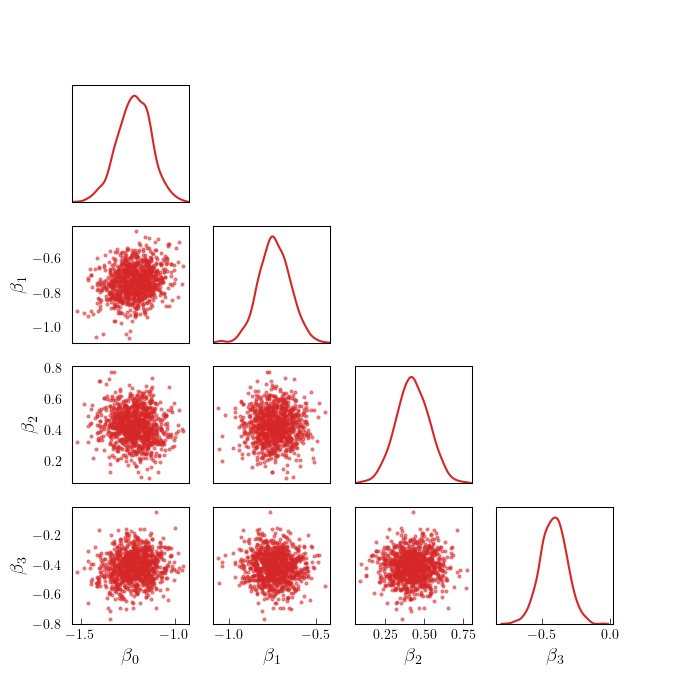

In [13]:
#| code-fold: true
#| fig-align: center
#| fig-cap: A pair plot showing samples from the posterior.
#| label: fig-samples

num_beta_plot = 4
num_thin = 10  # take every nth sample

samples_thinned = samples_dirt[::num_thin, :num_beta_plot]
labels = [r"$\beta_{"+f"{i}"+r"}$" for i in range(num_beta_plot)]
pairplot(samples_thinned, labels=labels)